<a href="https://colab.research.google.com/github/Yaroslavwvw/neural_networks/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%963_%D0%A1%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D1%8B%D0%B5_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5_%D1%81%D0%B5%D1%82%D0%B8_(CNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание №1. Использование глубокой сверточной нейронной сети для классификации предметов одежды на примере датасета Fashion MNIST


**В качестве интерфейса для работы с моделями используйте [Gradio](https://colab.research.google.com/drive/18EM8mrpURStkmbxWjZybWbWh23Si5b4A#scrollTo=-uu_VR8H2K4h)**

[Техническая документация по датасету](https://www.kaggle.com/datasets/zalando-research/fashionmnist)

## 1.1. Устанавливаем необходимые зависимости

In [ ]:
from keras.datasets import fashion_mnist # импорт исходного датасета
from keras.models import Sequential

from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

from keras.optimizers import Adam, SGD
import matplotlib.pyplot as plt
import numpy as np

## 1.2. Разделяем данные на обучающую и тестовую выборку

In [ ]:
(trainX, trainy), (testX, testy) = fashion_mnist.load_data()

print('Train: X = ', trainX.shape)
print('Test: X = ', testX.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: X =  (60000, 28, 28)
Test: X =  (10000, 28, 28)


## 1.3. Визуализируем часть данных из датасета

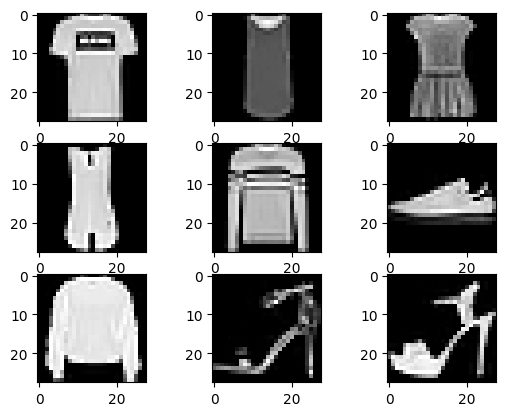

In [ ]:
for i in range(1, 10):
    plt.subplot(3, 3, i)
    plt.imshow(trainX[i], cmap=plt.get_cmap('gray'))

plt.show()

## 1.4. Создаём архитектуру нейронной сети и компилируем модель

In [ ]:
from keras.utils import to_categorical

# Нормализация данных
trainX = trainX.reshape((trainX.shape[0], 28, 28, 1)).astype('float32') / 255
testX = testX.reshape((testX.shape[0], 28, 28, 1)).astype('float32') / 255

# Преобразуем метки в one-hot encoding
trainy = to_categorical(trainy)
testy = to_categorical(testy)

# Создаем модель
model = Sequential()

# Добавляем слои
model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform'))
model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(100, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(10, activation='softmax'))

# Компилируем модель
model.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])

# Выводим информацию о модели
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 9, 9, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 4, 4, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100)                 │         102,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 159,254 (622.09 KB)

 Trainable params: 159,254 (622.09 KB)

 Non-trainable params: 0 (0.00 B)

## 1.5. Обучаем модель

In [ ]:
history = model.fit(trainX, trainy, epochs=10, batch_size=64, validation_data=(testX, testy), verbose=1)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 85ms/step - accuracy: 0.7541 - loss: 0.7423 - val_accuracy: 0.8527 - val_loss: 0.3928
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 87ms/step - accuracy: 0.8623 - loss: 0.3706 - val_accuracy: 0.8576 - val_loss: 0.3912
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 84ms/step - accuracy: 0.8733 - loss: 0.3440 - val_accuracy: 0.8606 - val_loss: 0.3842
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 84ms/step - accuracy: 0.8761 - loss: 0.3341 - val_accuracy: 0.8519 - val_loss: 0.4104
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 84ms/step - accuracy: 0.8761 - loss: 0.3297 - val_accuracy: 0.8583 - val_loss: 0.3971
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 80s 86ms/step - accuracy: 0.8778 - loss: 0.3285 - val_accuracy: 0.8751 - val_loss: 0.3471
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 80s 84ms/step - accuracy: 0.8804 - loss: 0.3210 - val_accuracy: 0.8744 - val_loss: 0.3396
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 80s 85ms/step - accuracy: 0.8875 - loss: 0.3051 - 

## 1.6. Анализируем обученную модель. Строим график (графики) обучения

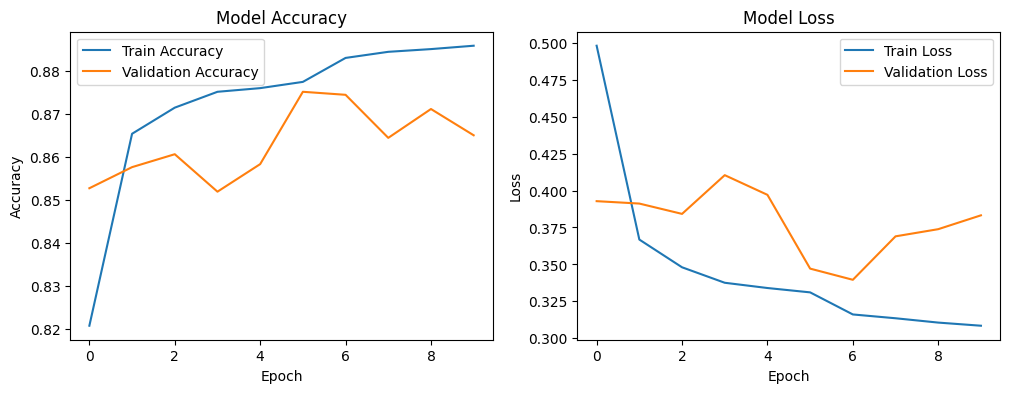

In [ ]:
# Построение графиков точности и потерь
plt.figure(figsize=(12, 4))

# График точности
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# График потерь
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

## 1.7. Загружаем свои изображения. С помощью функции predict() получаем предсказание нейронной сети



> Требуется получить предсказания минимум по 5 изображениям, каждое из которых относится к разному классу. Не забудьте добавить метки к каждому классу (для этого можно просто создать список строк, каждая из которых будет соответствовать классу с определенным индексом см. [тех.док.](https://www.kaggle.com/datasets/zalando-research/fashionmnist)). Процент уверенности нейронной сети в своём предсказании выводить обязательно.




Processing: coat.jpg
Input shape: (1, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


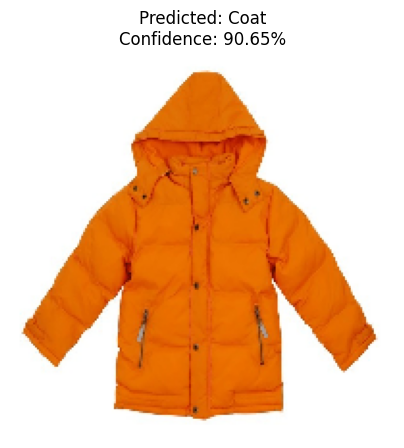

Result: Coat (90.65%)

Processing: dress.jpg
Input shape: (1, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


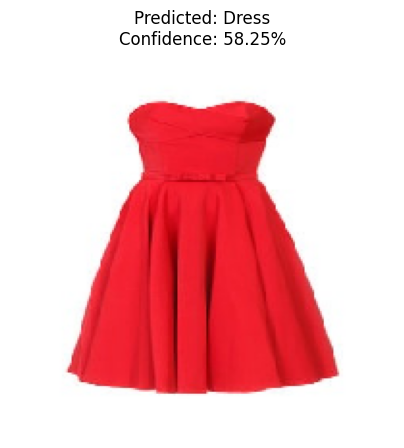

Result: Dress (58.25%)

Processing: sandal.jpg
Input shape: (1, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


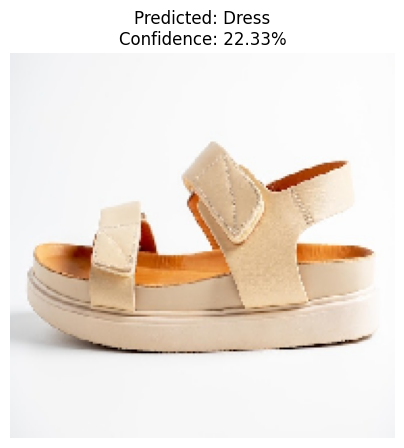

Result: Dress (22.33%)

Processing: sneaker.jpg
Input shape: (1, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


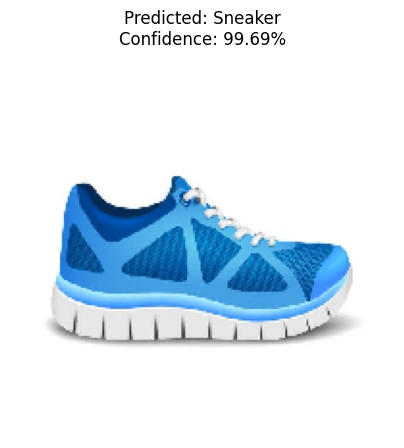

Result: Sneaker (99.69%)

Processing: tshirt.jpg
Input shape: (1, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


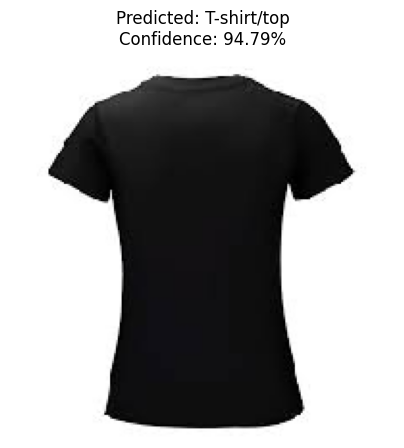

Result: T-shirt/top (94.79%)


In [ ]:
from keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Список меток классов
class_labels = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

def preprocess_image(img_path):
    # Загрузка изображения с явным указанием color_mode
    img = image.load_img(img_path, target_size=(28, 28), color_mode="grayscale")

    # Конвертация в массив
    img_array = image.img_to_array(img)

    # Инверсия цветов (активировать если нужно)
    img_array = 255 - img_array  # Раскомментировать для белого фона

    # Нормализация и преобразование формы
    img_array = img_array.reshape((1, 28, 28, 1)).astype('float32') / 255.0

    return img_array

def visualize_prediction(img_path, prediction, confidence):
    plt.figure(figsize=(5,5))

    # Показываем оригинальное изображение
    orig_img = image.load_img(img_path, target_size=(200, 200))

    plt.imshow(orig_img, cmap='gray')
    plt.title(f"Predicted: {prediction}\nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

def predict_and_visualize(img_path):
    try:
        # Предобработка
        processed_img = preprocess_image(img_path)

        # Проверка формы изображения
        print(f"Input shape: {processed_img.shape}")  # Должно быть (1, 28, 28, 1)

        # Предсказание
        prediction = model.predict(processed_img)
        predicted_class = np.argmax(prediction)
        confidence = np.max(prediction) * 100

        # Визуализация
        visualize_prediction(img_path, class_labels[predicted_class], confidence)

        return class_labels[predicted_class], confidence
    except Exception as e:
        print(f"Error: {str(e)}")
        raise

# Пример использования
image_paths = [
    "coat.jpg",
    "dress.jpg",
    "sandal.jpg",
    "sneaker.jpg",
    "tshirt.jpg"
]

for img_path in image_paths:
    try:
        print("\n" + "="*50)
        print(f"Processing: {img_path}")
        predicted_class, confidence = predict_and_visualize(img_path)
        print(f"Result: {predicted_class} ({confidence:.2f}%)")
    except Exception as e:
        print(f"Failed to process {img_path}: {str(e)}")

# Задание №2. Использование глубокой сверточной нейронной сети для классификации изображений по своему датасету


## 2.1.  Используя датасет, собранный для предыдущей работы, разработайте и обучите **свою** модель глубокой  **сверточной** нейронной сети для классификации изображений







In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kausthubkannan/5-flower-types-classification-dataset")

print("Path to dataset files:", path)

100%|██████████| 242M/242M [00:02<00:00, 120MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kausthubkannan/5-flower-types-classification-dataset/versions/1


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Путь к датасету
dataset_path = "/root/.cache/kagglehub/datasets/kausthubkannan/5-flower-types-classification-dataset/versions/1/flower_images"

# Параметры для загрузки данных
img_width, img_height = 150, 150
batch_size = 32

# Генератор данных для обучения и валидации
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Создание модели CNN
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

# Компиляция модели
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Обучение модели
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    epochs=10
)

Found 4000 images belonging to 5 classes.
Found 1000 images belonging to 5 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 285s 2s/step - accuracy: 0.4082 - loss: 1.7382 - val_accuracy: 0.5837 - val_loss: 1.0695
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.5622 - loss: 1.1031 - val_accuracy: 0.6179 - val_loss: 0.9876
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 278s 2s/step - accuracy: 0.6114 - loss: 0.9950 - val_accuracy: 0.6472 - val_loss: 0.9215
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.6479 - loss: 0.9058 - val_accuracy: 0.6744 - val_loss: 0.9007
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 281s 2s/step - accuracy: 0.6632 - loss: 0.8544 - val_accuracy: 0.6946 - val_loss: 0.8104
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.7135 - loss: 0.7527 - val_accuracy: 0.7218 - val_loss: 0.7481
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.7395 - loss: 0.6651 - val_accuracy: 0.7460 - val_loss: 0.7302
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.7805 - loss: 0.6263 - val_accu

## 2.2.   Ознакомьтесь с современными архитектурами сверточных нейронных сетей: [см. ссылку](https://medium.com/aiguys/how-cnn-architectures-evolved-c53d3819fef8). На основе рассмотренных архитектур, реализуйте (частично повторяя основные паттерны проектирования) и обучите модель сверточной нейронной сети. Укажите архитектуру, которой Вы "вдохновились"

In [ ]:
from tensorflow.keras.layers import Input, Add, Activation, BatchNormalization, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

def ResidualBlock(x, filters, kernel_size=3, change_channels=False):
    shortcut = x
    # Добавляем 1x1 свертку, если нужно изменить число каналов
    if change_channels:
        shortcut = Conv2D(filters, (1, 1), padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Conv2D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x

# Создание модели
input_layer = Input(shape=(150, 150, 3))
x = Conv2D(64, (7, 7), padding='same', activation='relu')(input_layer)
x = MaxPooling2D((3, 3))(x)

# Блоки с изменением числа фильтров
x = ResidualBlock(x, 64)  # Фильтры 64 -> 64 (change_channels=False)
x = MaxPooling2D((2, 2))(x)

x = ResidualBlock(x, 128, change_channels=True)  # Фильтры 64 -> 128
x = MaxPooling2D((2, 2))(x)

x = ResidualBlock(x, 256, change_channels=True)  # Фильтры 128 -> 256

x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output_layer = Dense(5, activation='softmax')(x)

resnet_model = Model(inputs=input_layer, outputs=output_layer)

# Компиляция и обучение
resnet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_resnet = resnet_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    epochs=10
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 585s 5s/step - accuracy: 0.4260 - loss: 1.4144 - val_accuracy: 0.3740 - val_loss: 1.5213
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 619s 5s/step - accuracy: 0.5379 - loss: 1.1405 - val_accuracy: 0.3407 - val_loss: 2.2332
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 565s 5s/step - accuracy: 0.5750 - loss: 1.0750 - val_accuracy: 0.3155 - val_loss: 3.3230
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 681s 5s/step - accuracy: 0.6022 - loss: 1.0301 - val_accuracy: 0.5433 - val_loss: 1.1526
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 681s 5s/step - accuracy: 0.6098 - loss: 0.9940 - val_accuracy: 0.4990 - val_loss: 1.3619
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 563s 5s/step - accuracy: 0.6543 - loss: 0.9058 - val_accuracy: 0.6038 - val_loss: 1.0085
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 682s 5s/step - accuracy: 0.6499 - loss: 0.8977 - val_accuracy: 0.5151 - val_loss: 1.4062
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 622s 5s/step - accuracy: 0.6654 - loss: 0.8517 - val_accu

## 2.3. Сохраните полученные модели

In [ ]:
resnet_model.save('resnet_inspired_model.h5')

In [ ]:
model.save('basic_cnn_model.h5')

## 2.4. Загрузите обученную модель из прошлой практической работы


In [ ]:
from tensorflow.keras.models import load_model
import pickle
from sklearn.preprocessing import LabelBinarizer

# Загрузка модели
model = load_model('flower_classifier.h5')

# Загрузка меток классов из LabelBinarizer
try:
    with open('label_bin.pickle', 'rb') as f:
        lb = pickle.load(f)
    class_labels = lb.classes_.tolist()
except:
    # Если файл недоступен, используйте генератор данных
    class_labels = list(train_generator.class_indices.keys())

print("Метки классов:", class_labels)

Метки классов: ['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip']



## 2.5. Сравните между собой точной всех трёх моделей, подавая на вход одинаковые изображения (15 разных изображений). Сравните предсказания каждой из моделей и сделайте выводы

Метки классов: ['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 830ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

Результаты:
- Базовая CNN: 100.00%
- ResNet: 73.33%
- Прошлая модель: 13.33%


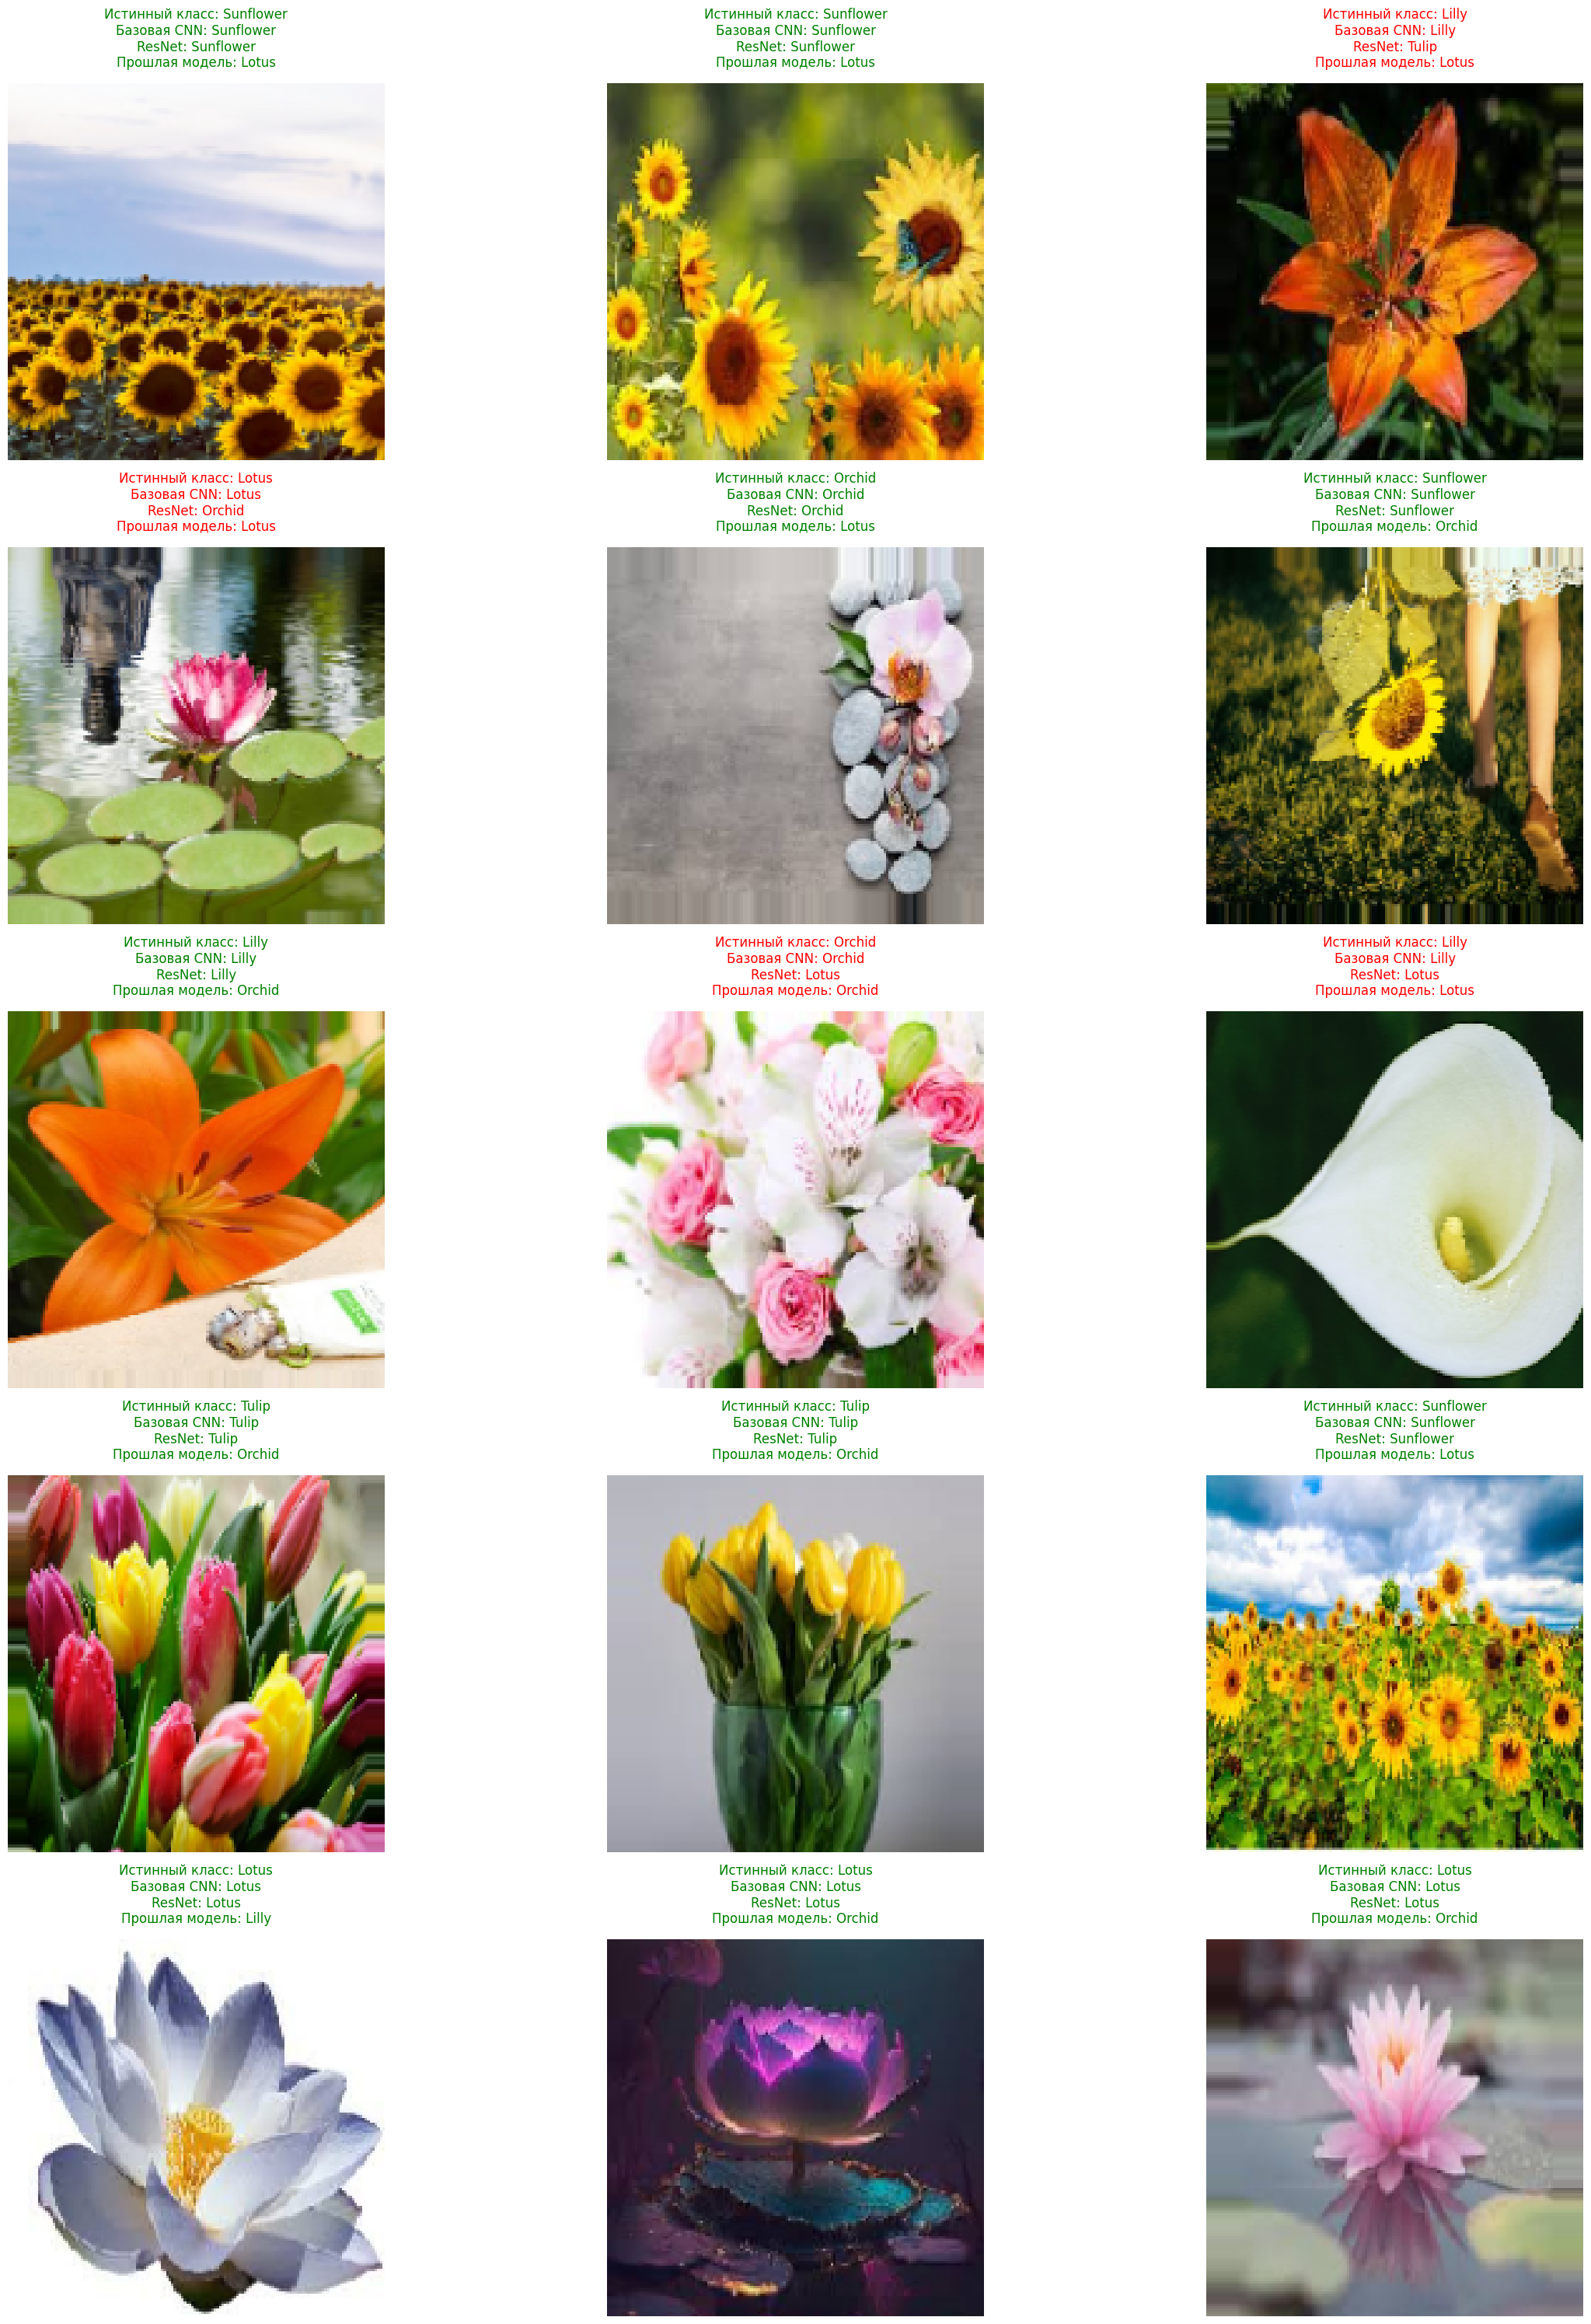

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import load_model
import pickle
from sklearn.preprocessing import LabelBinarizer

# -------------------------------
# 1. Загрузка моделей и меток классов
# -------------------------------
basic_model = load_model('basic_cnn_model.h5')       # Модель из 2.1
resnet_model = load_model('resnet_inspired_model.h5')# Модель из 2.2
previous_model = load_model('flower_classifier.h5')     # Модель из прошлой работы

# Загрузка меток классов
try:
    with open('label_bin.pickle', 'rb') as f:
        lb = pickle.load(f)
    class_labels = lb.classes_.tolist()
except:
    class_labels = list(train_generator.class_indices.keys())

print("Метки классов:", class_labels)

# -------------------------------
# 2. Подготовка данных
# -------------------------------
def preprocess_for_previous_model(images):
    """Преобразует изображения в формат для прошлой модели (64x64 -> flat vector)"""
    processed = []
    for img in images:
        resized = cv2.resize(img * 255, (64, 64))  # Отмена нормализации и изменение размера
        flattened = resized.reshape(-1) / 255.0    # Нормализация и выравнивание
        processed.append(flattened)
    return np.array(processed)

# Загрузка 15 тестовых изображений
validation_generator.reset()
test_images, test_labels = next(validation_generator)
test_images = test_images[:15]
test_true = np.argmax(test_labels[:15], axis=1)

# Преобразование данных для прошлой модели
test_images_flat = preprocess_for_previous_model(test_images)

# -------------------------------
# 3. Предсказания моделей
# -------------------------------
# Для CNN и ResNet
pred_basic = np.argmax(basic_model.predict(test_images), axis=1)
pred_resnet = np.argmax(resnet_model.predict(test_images), axis=1)

# Для прошлой модели (требует flat-векторы)
pred_previous = np.argmax(previous_model.predict(test_images_flat), axis=1)

# -------------------------------
# 4. Расчет точности
# -------------------------------
def calculate_accuracy(true, pred):
    return np.sum(true == pred) / len(true)

acc_basic = calculate_accuracy(test_true, pred_basic)
acc_resnet = calculate_accuracy(test_true, pred_resnet)
acc_previous = calculate_accuracy(test_true, pred_previous)

print("\nРезультаты:")
print(f"- Базовая CNN: {acc_basic:.2%}")
print(f"- ResNet: {acc_resnet:.2%}")
print(f"- Прошлая модель: {acc_previous:.2%}")

# -------------------------------
# 5. Визуализация предсказаний
# -------------------------------
plt.figure(figsize=(25, 30))
for i in range(15):
    plt.subplot(5, 3, i+1)

    # Отображение изображения (150x150)
    plt.imshow(test_images[i])

    # Формирование заголовка
    true_label = class_labels[test_true[i]]
    basic_label = class_labels[pred_basic[i]]
    resnet_label = class_labels[pred_resnet[i]]
    previous_label = class_labels[pred_previous[i]]

    title = (
        f"Истинный класс: {true_label}\n"
        f"Базовая CNN: {basic_label}\n"
        f"ResNet: {resnet_label}\n"
        f"Прошлая модель: {previous_label}"
    )

    # Цвет текста
    color = "green" if true_label == resnet_label else "red"
    plt.title(title, fontsize=12, color=color, pad=15)
    plt.axis('off')

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120)
plt.show()

# Задание №3*. Использование глубокой сверточной нейронной сети для восстановления изображения

## 3.1. Работа с данными

Будем работать с набором данным `fetch_olivetti_faces` из `sklearn`.

### 3.1.1. Переведите векторы в настоящие изображения из двух размерностей

In [ ]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

data, _ = fetch_olivetti_faces(return_X_y=True)
train, test = train_test_split(data, test_size=0.2, random_state=4)

In [ ]:
train.shape

(320, 4096)

Сейчас изображение - это вектор, имеющий размерность 4096.

In [ ]:
# Ваш код здесь

train = train.reshape((train.shape[0], 64, 64))
test = test.reshape((test.shape[0], 64, 64))

test.shape

(80, 64, 64)

### 3.1.2. Отрисуйте несколько примеров

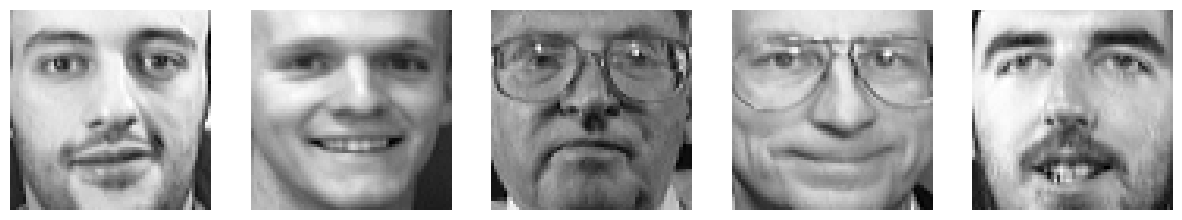

In [ ]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    ax[i].imshow(train[i], cmap='gray')
    ax[i].axis('off')

Поделим данные на X и y, где X - это верхняя часть лица человека, на этом модель будет обучаться, а y - это нижняя часть лица человека - её будем предсказывать.

In [ ]:
n_pixels = train.shape[1]

# Upper half of the faces
X_train = train[:, :(n_pixels + 1) // 2, :]
# Lower half of the faces
y_train = train[:, n_pixels // 2:, :]


X_test = test[:, :(n_pixels + 1) // 2, :]
y_test = test[:, n_pixels // 2:, :]

In [ ]:
X_train.shape

(320, 32, 64)

Вот один пример обучающей пары.

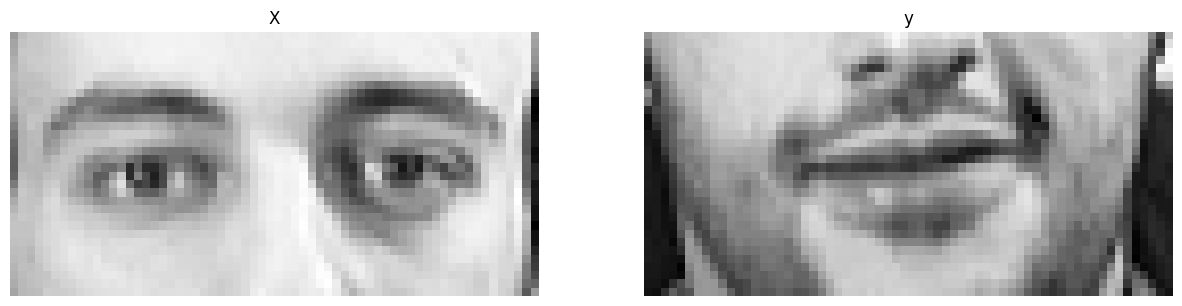

In [ ]:
import matplotlib.pyplot as plt

idx = 0

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(X_train[idx], cmap='gray')
ax[0].set_title('X')
ax[1].imshow(y_train[idx], cmap='gray')
ax[1].set_title('y')
ax[0].axis('off')
ax[1].axis('off')

plt.show()

### 3.1.3. Измените размерность y
Остается только изменить размерность y, т.к. сейчас $y$ - картинка 32x64, а выход нейронной сети у нас будет одномерный и равный 32 * 64 = 2048.

In [ ]:
y_train_n = y_train.reshape(y_train.shape[0], 32 * 64)
y_test_n = y_test.reshape(y_test.shape[0], 32 * 64)

y_train_n.shape

(320, 2048)

## 3.2. Создайте архитектуру для этой задачи

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, InputLayer

model = Sequential([
    InputLayer(input_shape=(32, 64, 1)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Flatten(),
    Dense(2048, activation='sigmoid')
])

## 3.3. Скомпилируйте сеть

Подберите нужную функцию потерь и метрику. Оптимизатор можете использовать 'adam'

In [ ]:
model.compile(optimizer='adam',
              loss='mean_absolute_error',
              metrics=['mae'])

## 3.4. Обучите нейросеть

Выберите нужное количество эпох.


In [ ]:
# Подготовка данных для модели
X_train_reshaped = X_train.reshape(-1, 32, 64, 1)
X_test_reshaped = X_test.reshape(-1, 32, 64, 1)

# Обучение модели
history = model.fit(
    X_train_reshaped,
    y_train_n,
    epochs=70,
    batch_size=32,
    validation_data=(X_test_reshaped, y_test_n))

Epoch 1/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 408ms/step - loss: 0.1743 - mae: 0.1743 - val_loss: 0.1230 - val_mae: 0.1230
Epoch 2/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.1214 - mae: 0.1214 - val_loss: 0.1143 - val_mae: 0.1143
Epoch 3/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.1147 - mae: 0.1147 - val_loss: 0.1122 - val_mae: 0.1122
Epoch 4/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.1146 - mae: 0.1146 - val_loss: 0.1104 - val_mae: 0.1104
Epoch 5/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.1096 - mae: 0.1096 - val_loss: 0.1081 - val_mae: 0.1081
Epoch 6/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.1071 - mae: 0.1071 - val_loss: 0.1049 - val_mae: 0.1049
Epoch 7/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.1053 - mae: 0.1053 - val_loss: 0.1009 - val_mae: 0.1009
Epoch 8/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.0962 - mae: 0.0962 - val_loss: 0.0921 - val_mae: 0.0921
Epoch 9/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.08

## 3.5. Сделайте предсказания на тестовых данных

In [ ]:
pred_test = model.predict(X_test_reshaped)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step


## 3.6. Посчитайте метрику качества на тестовых данных

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(pred_test, y_test_n)
print(f'MAE: {mae:.4f}')

MAE: 0.0727


## 3.7. Преобразуйте предсказанные векторы в двумерное изображение (поменяйте их размерность)

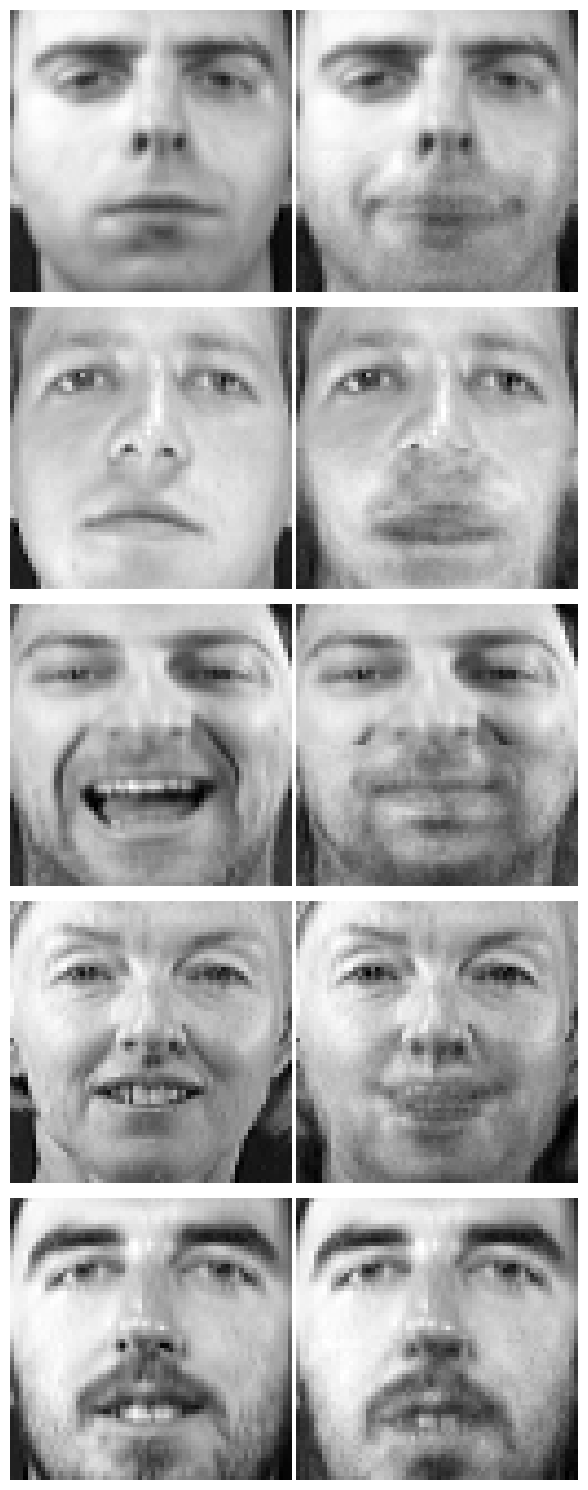

In [ ]:
pred_test_images = pred_test.reshape(-1, 32, 64)

# Визуализация результатов
import numpy as np

n_faces = 5
n_cols = 2
image_shape = (64, 64)
plt.figure(figsize=(3 * n_cols, 3 * n_faces))

for i in range(n_faces):
    # Оригинальное изображение
    true_face = np.vstack((X_test[i], y_test[i]))

    # Предсказанное изображение
    completed_face = np.vstack((X_test[i], pred_test_images[i]))

    # Отрисовка
    plt.subplot(n_faces, n_cols, i*2 + 1)
    plt.imshow(true_face, cmap='gray')
    plt.axis('off')

    plt.subplot(n_faces, n_cols, i*2 + 2)
    plt.imshow(completed_face, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

Отрисуйте все предсказания.

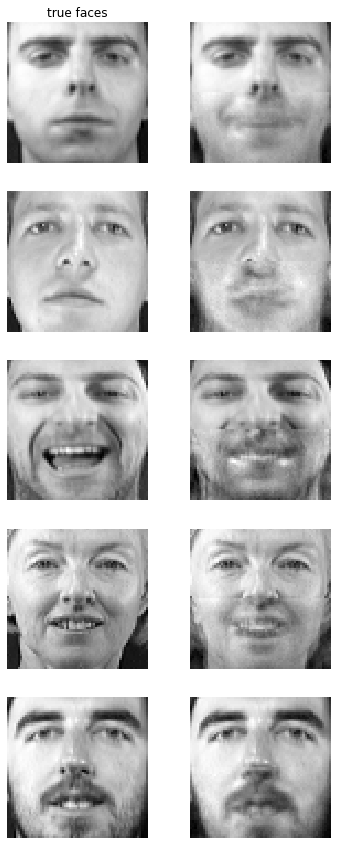

In [ ]:
# Пример кода:

n_faces = 5
n_cols = 2
image_shape = (64, 64)
plt.figure(figsize=(3 * n_cols, 3 * n_faces))


for i in range(5):
    true_face = np.vstack((X_test[i], y_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1)
    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1, title="true faces")

    sub.axis("off")
    sub.imshow(
        true_face.reshape(image_shape), cmap=plt.cm.gray, interpolation="nearest"
    )

    completed_face = np.vstack((X_test[i], pred_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 2)

    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 2)

    sub.axis("off")
    sub.imshow(
        completed_face.reshape(image_shape),
        cmap=plt.cm.gray,
        interpolation="nearest",
    )